In [12]:
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import *
from fintorch.utils.preprocess import *

In [2]:
args = DefaultArgumentParser.parse(args=[])

Output()

Output()

Output()

In [3]:
dc = args.online_exchange.future.data.get_data_collection(symbols=args.symbols, time_frames=args.time_frames)
sdf = dc.get_candles_df(symbol=args.symbol, time_frame=args.time_frame)

sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1569412800,8324.27,8460.00,8242.61,8293.28,9081.314,16760.0
1569427200,8295.79,8408.31,8223.71,8346.96,6397.273,12250.0
1569441600,8346.96,8628.44,8332.41,8430.07,9155.947,11781.0
1569456000,8428.15,8443.55,8316.61,8361.80,4251.146,6539.0
1569470400,8361.82,8431.00,8335.72,8379.00,3154.622,6681.0
...,...,...,...,...,...,...
1714377600,62362.10,62658.70,62150.00,62222.90,22955.752,398520.0
1714392000,62222.60,63085.00,61726.20,63012.20,66488.045,956030.0
1714406400,63012.20,63227.30,62511.10,62953.40,30356.738,472654.0


In [24]:
count = 1000
muting_percentage = 90

df = remove_price_dependency(df=sdf, inplace=False)[-count:]
df = remove_noise_fft(df=df, muting_percentage=muting_percentage)
df.insert(0, "datetime", [datetime.fromtimestamp(ts) for ts in df.index])
df["label"] = df["clean-open"] < df["clean-close"]

print(df.label.value_counts())

df

label
True     546
False    454
Name: count, dtype: int64


,datetime,open,high,low,close,volume,trade,clean-open,clean-high,clean-low,clean-close,label
timestamp,,,,,,,,,,,,
1700049600,2023-11-15 15:30:00,2.393369,2.398209,2.386854,2.397716,63657.595,644609.0,2.679971,2.691665,2.664639,2.684474,True
1700064000,2023-11-15 19:30:00,2.397716,2.437065,2.393426,2.428343,177826.354,1564373.0,2.615809,2.627585,2.598848,2.619636,True
1700078400,2023-11-15 23:30:00,2.428343,2.440936,2.422797,2.437888,82467.190,854812.0,2.556194,2.567820,2.538842,2.559255,True
1700092800,2023-11-16 03:30:00,2.437888,2.439762,2.423853,2.427182,53899.391,570253.0,2.503680,2.514879,2.487274,2.505930,True
1700107200,2023-11-16 07:30:00,2.427182,2.431614,2.423745,2.426672,27546.983,328016.0,2.459992,2.470512,2.445731,2.461410,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1714377600,2024-04-29 11:30:00,2.995045,2.999801,2.991644,2.992813,22955.752,398520.0,2.961303,2.971373,2.958298,2.964842,True
1714392000,2024-04-29 15:30:00,2.992813,3.006673,2.984835,3.005503,66488.045,956030.0,2.919301,2.929829,2.914831,2.923888,True
1714406400,2024-04-29 19:30:00,3.005503,3.008916,2.997550,3.004569,30356.738,472654.0,2.868064,2.878933,2.861219,2.873213,True


/home/sahand/.local/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/home/sahand/.local/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  w

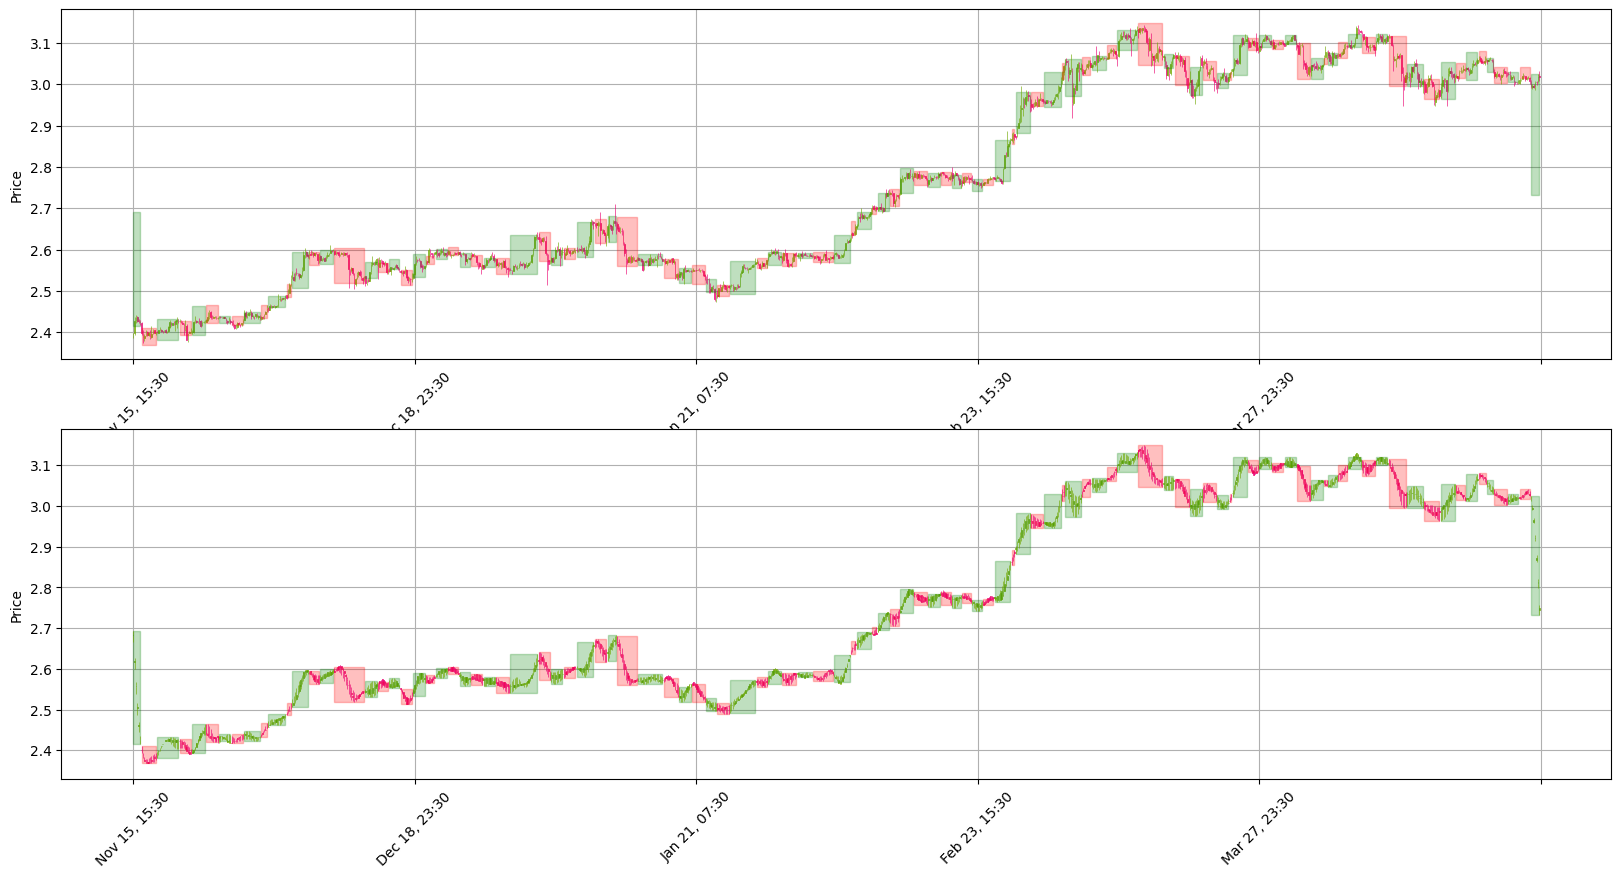

In [25]:
pdf = df.copy()
pdf["open"] = df["clean-open"]
pdf["high"] = df["clean-high"]
pdf["low"] = df["clean-low"]
pdf["close"] = df["clean-close"]

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 10))
draw_candlestick_plot(ax=axs[0], df=df[-count:])
draw_candlestick_plot(ax=axs[1], df=pdf)
draw_labels(ohlc_ax=axs[0], df=pdf)
draw_labels(ohlc_ax=axs[1], df=pdf)
axs[0].grid()
axs[1].grid()